Dataset Exploration, Preprocessing and Visualization

     folder                      timestamp camera_type      image_name  \
0  image_00  2011-09-26 13:02:25.967790592   grayscale  0000000000.png   
1  image_00  2011-09-26 13:02:26.070920448   grayscale  0000000001.png   
2  image_00  2011-09-26 13:02:26.174361088   grayscale  0000000002.png   
3  image_00  2011-09-26 13:02:26.277073920   grayscale  0000000003.png   
4  image_00  2011-09-26 13:02:26.380190208   grayscale  0000000004.png   

                                          image_path  
0  D:\Autonomous_project\KITTI_dataset\raw_datase...  
1  D:\Autonomous_project\KITTI_dataset\raw_datase...  
2  D:\Autonomous_project\KITTI_dataset\raw_datase...  
3  D:\Autonomous_project\KITTI_dataset\raw_datase...  
4  D:\Autonomous_project\KITTI_dataset\raw_datase...  


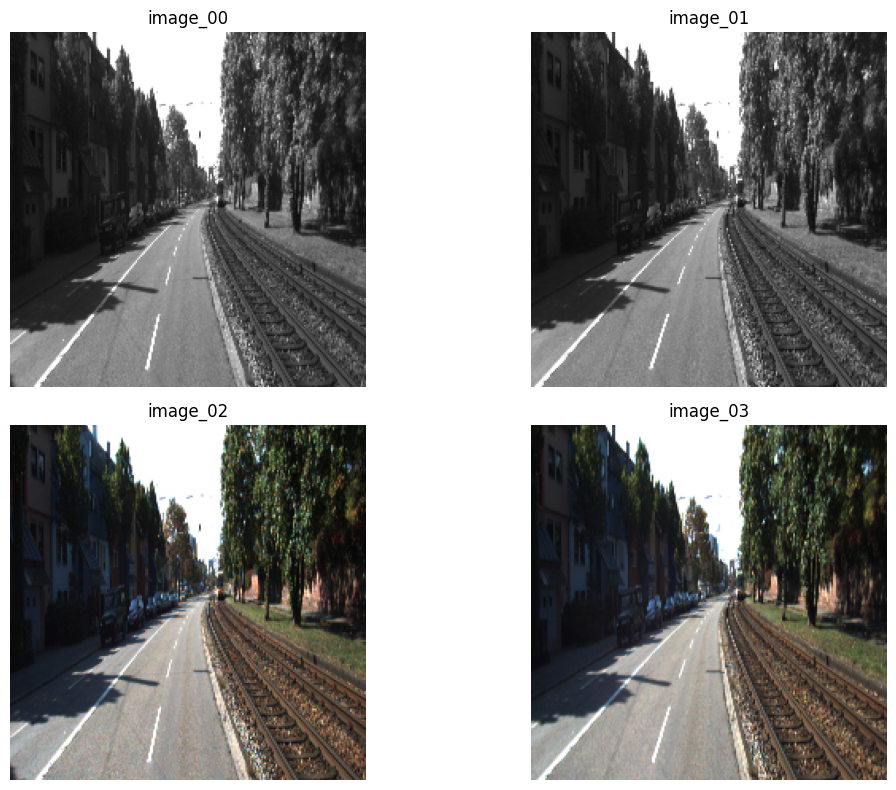

In [4]:
print("Dataset Exploration, Preprocessing and Visualization\n")
import os # to handle file operations
import cv2 # to load images
import pandas as pd 
from PIL import Image #visualization
import matplotlib.pyplot as plt #visualization

#define base path where the dataset exists to load images, lidar and GPS IMU data
base_path = r"D:\Autonomous_project\KITTI_dataset\raw_dataset\2011_09_26\2011_09_26_drive_0001_sync"

# define subfolders to load images from left right camera images for grayscale (img_00,img_01) and RGB (img_02, img_03)
folders = ["image_00", "image_01", "image_02", "image_03"]

# initialize a list to store data information such as images, timestamps and type of image
data_info = []

# initialize a dictionary to store the images
images = {}

# iterate through each folder and load images and timestamps
for folder in folders:
    folder_path = os.path.join(base_path, folder, "data")
    timestamps_file = os.path.join(base_path, folder, "timestamps.txt")
 
    # Check if the folder exists
    if os.path.exists(folder_path):
        images[folder] = []  # initialize a list for each folder

        # Load timestamps
        with open(timestamps_file, 'r') as f:
            timestamps = f.read().strip().split('\n')

        # Load all the images gray scale and RBG
        for idx, img_name in enumerate(sorted(os.listdir(folder_path))):
            img_path = os.path.join(folder_path, img_name)

            # Load image using OpenCV 
            img = cv2.imread(img_path)

            # Convert BGR to RGB for visualization
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize image to 224x224 for consistency
            img_resized = cv2.resize(img_rgb, (224, 224))

            # Append image and metadata
            images[folder].append(img_resized)
            data_info.append({
                "folder": folder,
                "timestamp": timestamps[idx] if idx < len(timestamps) else None,
                "camera_type": "grayscale" if "image_00" in folder or "image_01" in folder else "color",
                "image_name": img_name,
                "image_path": img_path
            })

# Convert data_info to a Pandas DataFrame
data_df = pd.DataFrame(data_info)

# Display first few 5 of the DataFrame
print(data_df.head())

# Display a few images from each folder
plt.figure(figsize=(12, 8))
for i, folder in enumerate(folders):
    if folder in images and len(images[folder]) > 0:
        plt.subplot(2, 2, i + 1)
        plt.imshow(images[folder][0])  # Show the first image from the folder to check if the images are laoded and processed properly
        plt.title(f"{folder}")
        plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:
print("Define Object Based Labels as given in the KITTI Website for this Raw Dataset")
# Define object-based labels manually from the information provided in the Kitti website fot raw data
object_labels = {
    "image_00": {"cars": 12, "vans": 0, "trucks": 0, "pedestrians": 0, "cyclists": 2, "trams": 1, "misc": 0},
    "image_01": {"cars": 12, "vans": 0, "trucks": 0, "pedestrians": 0, "cyclists": 2, "trams": 1, "misc": 0},
    "image_02": {"cars": 12, "vans": 0, "trucks": 0, "pedestrians": 0, "cyclists": 2, "trams": 1, "misc": 0},
    "image_03": {"cars": 12, "vans": 0, "trucks": 0, "pedestrians": 0, "cyclists": 2, "trams": 1, "misc": 0},
}

# Add these labels to the pandas DataFrame
data_df['object_labels'] = data_df['folder'].map(object_labels)

# Display the updated DataFrame with labels added
print(data_df[['image_name', 'folder', 'object_labels']].head())


Define Object Based Labels as given in the KITTI Website for this Raw Dataset
       image_name    folder                                      object_labels
0  0000000000.png  image_00  {'cars': 12, 'vans': 0, 'trucks': 0, 'pedestri...
1  0000000001.png  image_00  {'cars': 12, 'vans': 0, 'trucks': 0, 'pedestri...
2  0000000002.png  image_00  {'cars': 12, 'vans': 0, 'trucks': 0, 'pedestri...
3  0000000003.png  image_00  {'cars': 12, 'vans': 0, 'trucks': 0, 'pedestri...
4  0000000004.png  image_00  {'cars': 12, 'vans': 0, 'trucks': 0, 'pedestri...


Visualiza Labelled Data


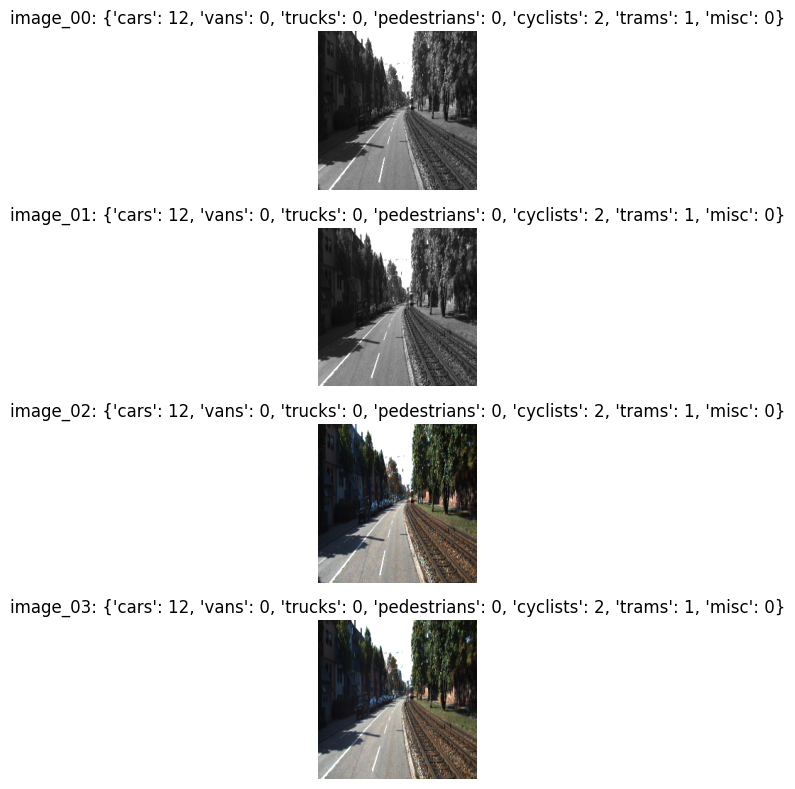

In [6]:
print("Visualiza Labelled Data")
plt.figure(figsize=(15, 8))
for i, folder in enumerate(folders):
    if folder in images and len(images[folder]) > 0:
        plt.subplot(4, 1, i + 1)
        plt.imshow(images[folder][0])  # Show the first image from the folder
        plt.title(f"{folder}: {object_labels[folder]}")
        plt.axis("off")
plt.tight_layout()
plt.show()


# Simple CNN

In [7]:
print("Convert images and labels to numpy array and split the dataset into training, testing and validation")
import os #file operations
import numpy as np #handling numerical data for this dataset converting numerical data to arrays
import tensorflow as tf #building and training cnn models
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input #import the layers for neural network
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping #import callbacks for stopping the model if the accuracy does not improve or the loss does not reduce 
from sklearn.model_selection import train_test_split #standard split the raw data into training and testing data
import matplotlib.pyplot as plt #visualization

# Load and preprocess images
#define base path and image folder paths 
base_path = r"D:\Autonomous_project\KITTI_dataset\raw_dataset\2011_09_26\2011_09_26_drive_0001_sync"
folders = ["image_00", "image_01", "image_02", "image_03"]
image_size = (224, 224) #resizing the images (standard size for CNN models)

X = []  # define a empty list for images
y = []  # define a empty list for labels

label_map = {"car": 0, "cyclist": 1, "tram": 2}  #define the classes based on the information in the kitti database

for folder in folders:
    folder_path = os.path.join(base_path, folder, "data")
    for img_name in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=image_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # Normalize
        X.append(img_array)

        # Assign a label based on the folder as defined in kitti database
        if "image_00" in folder:
            y.append(label_map["car"])
        elif "image_01" in folder:
            y.append(label_map["cyclist"])
        elif "image_02" in folder:
            y.append(label_map["tram"])
        else:
            y.append(label_map["car"])  

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



Convert images and labels to numpy array and split the dataset into training, testing and validation


In [6]:
# Build a simple CNN model
model = Sequential([
    Input(shape=(224, 224, 3)),  # Explicitly define input shape as standard image resolution for cnn models
    #insert convolutional networks with relu activation function to introduce non-linearity
    #relu converts negative vaklues to 0's 
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_map), activation='softmax') #softmax activation function because of comparision of true and predicted probabilities
])

# Compile the model using adam optimizer and l2 loss 
#adam optimizer benifiting both computational speed and rms probabilities
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,#tilt
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train) #train dataset is used for training



In [15]:
# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_test, y_test),
                    epochs=50)


Epoch 1/50


C:\Users\shubh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 949ms/step - accuracy: 0.3466 - loss: 1.6722 - val_accuracy: 0.5978 - val_loss: 0.9824
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 868ms/step - accuracy: 0.4664 - loss: 1.0754 - val_accuracy: 0.5978 - val_loss: 1.0494
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 881ms/step - accuracy: 0.4959 - loss: 1.0592 - val_accuracy: 0.5978 - val_loss: 1.0538
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 815ms/step - accuracy: 0.4651 - loss: 1.0650 - val_accuracy: 0.5978 - val_loss: 0.9557
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 816ms/step - accuracy: 0.5212 - loss: 1.0021 - val_accuracy: 0.5326 - val_loss: 0.8652
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 803ms/step - accuracy: 0.4640 - loss: 0.9585 - val_accuracy: 0.4457 - val_loss: 1.0335
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 828ms/step - accuracy: 0.4883 - loss: 0.8867 - val_accuracy: 0.4239 - val_loss: 1.4916
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 814ms/step - accuracy: 0.5463 - loss: 0.7627 - val_accuracy: 0.500

In [16]:
# Evaluate the model
loss, accuracy_cnn = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy_cnn * 100:.2f}%")



3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.4976 - loss: 1.9140
Test Accuracy: 51.09%


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step

Classification Report:
              precision    recall  f1-score   support

         car       0.62      0.47      0.54        55
     cyclist       0.57      0.20      0.30        20
        tram       0.40      1.00      0.57        17

    accuracy                           0.51        92
   macro avg       0.53      0.56      0.47        92
weighted avg       0.57      0.51      0.49        92



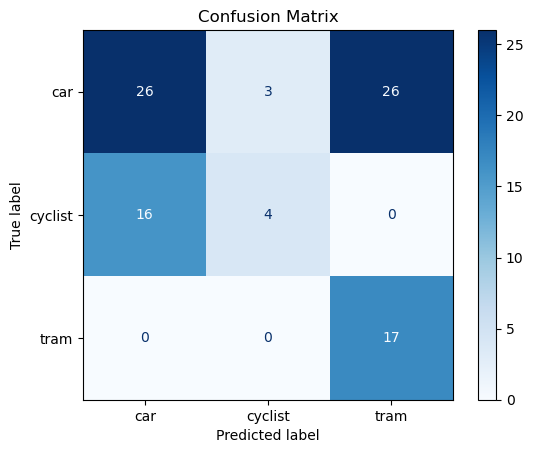

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=label_map.keys())

# Plot Confusion Matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


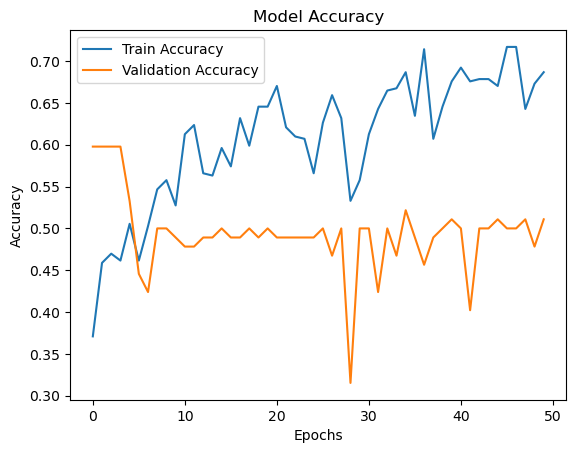

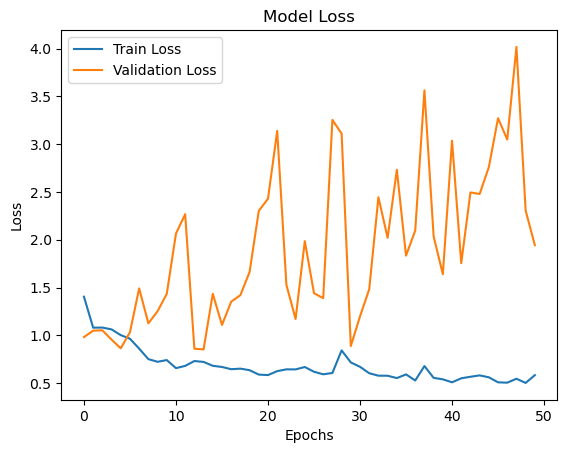

In [18]:
# Visualize training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# VGG16

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
# Load VGG16 model with pre-trained weights from imagenet/ dont include top is to exclude the fully connected layes to be used during training
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers not to be modified 
for layer in vgg_base.layers:
    layer.trainable = False

# Add custom classification layers
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_map), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)


In [29]:
# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_test, y_test),
                    epochs=50
                    )


Epoch 1/50


C:\Users\shubh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.3207 - loss: 3.1722 - val_accuracy: 0.5652 - val_loss: 0.9198
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 44s 4s/step - accuracy: 0.3810 - loss: 1.0953 - val_accuracy: 0.6304 - val_loss: 0.8629
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5422 - loss: 1.0241 - val_accuracy: 0.6087 - val_loss: 0.8220
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.4862 - loss: 0.9510 - val_accuracy: 0.6630 - val_loss: 0.8248
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.4909 - loss: 0.9447 - val_accuracy: 0.7935 - val_loss: 0.7364
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5538 - loss: 0.8611 - val_accuracy: 0.6522 - val_loss: 0.7496
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5681 - loss: 0.8534 - val_accuracy: 0.7283 - val_loss: 0.7584
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5599 - loss: 0.8136 - val_accuracy: 0.6630 - val_loss: 0.6812
Epo

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.9190 - loss: 0.3519
Test Accuracy: 92.39%
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step

Classification Report:
              precision    recall  f1-score   support

         car       0.93      0.95      0.94        55
     cyclist       0.86      0.90      0.88        20
        tram       1.00      0.88      0.94        17

    accuracy                           0.92        92
   macro avg       0.93      0.91      0.92        92
weighted avg       0.93      0.92      0.92        92



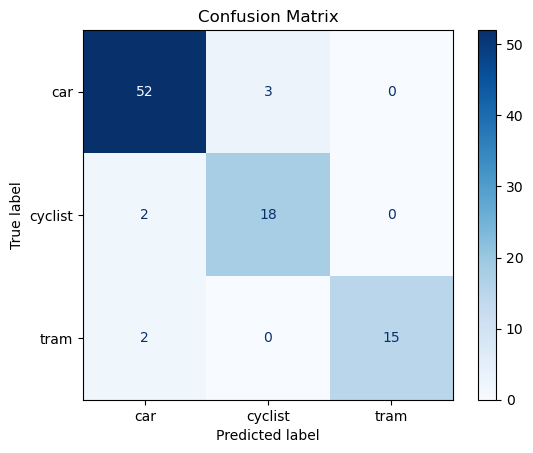

In [30]:
# Evaluate the model
loss, accuracy_vgg16 = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy_vgg16 * 100:.2f}%")

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=label_map.keys())

# Plot Confusion Matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


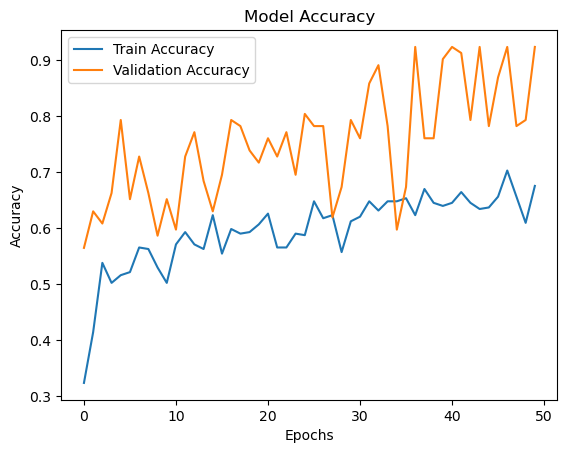

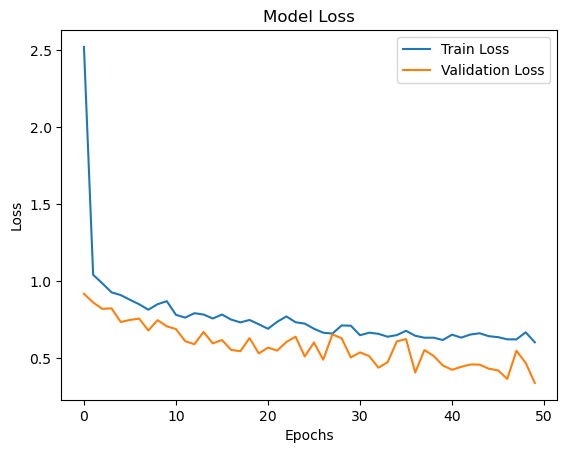

In [31]:
# Visualize training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ResNet

In [33]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


# Load ResNet50 model with pre-trained weights
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in resnet_base.layers:
    layer.trainable = False

# Add custom classification layers
model = Sequential([
    resnet_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_map), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)


In [34]:
# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_test, y_test),
                    epochs=50
                   )


Epoch 1/50


C:\Users\shubh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.3766 - loss: 6.6993 - val_accuracy: 0.2174 - val_loss: 1.5484
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.3372 - loss: 1.1867 - val_accuracy: 0.5978 - val_loss: 1.2382
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5014 - loss: 1.2675 - val_accuracy: 0.5978 - val_loss: 1.0942
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4711 - loss: 1.0959 - val_accuracy: 0.5978 - val_loss: 1.0915
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.5025 - loss: 1.0937 - val_accuracy: 0.5978 - val_loss: 1.0882
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4617 - loss: 1.0930 - val_accuracy: 0.5978 - val_loss: 1.0849
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.4749 - loss: 1.0907 - val_accuracy: 0.5978 - val_loss: 1.0813
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.4734 - loss: 1.0890 - val_accuracy: 0.5978 - val_loss: 1.0782
Epo

In [35]:
# Evaluate the model
loss, accuracy_resnet = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy_resnet * 100:.2f}%")

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=label_map.keys())


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5802 - loss: 1.0085
Test Accuracy: 59.78%
2/3 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001CBF7EAEAC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step

Classification Report:
              precision    recall  f1-score   support

         car       0.60      1.

C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\shubh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


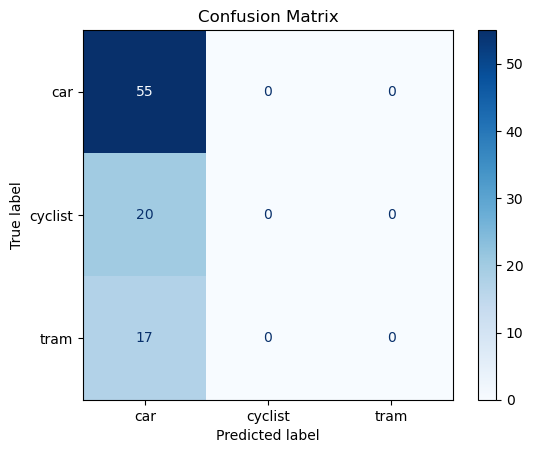

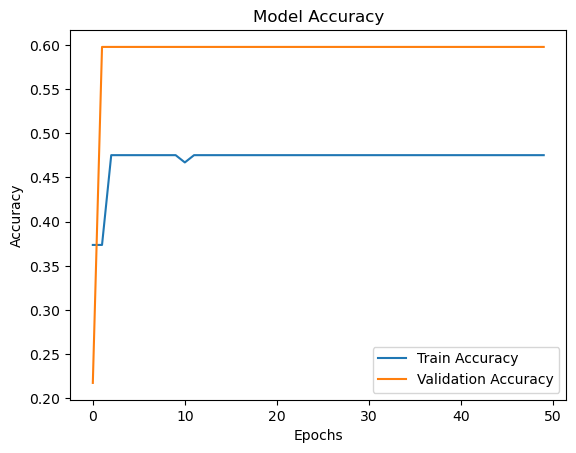

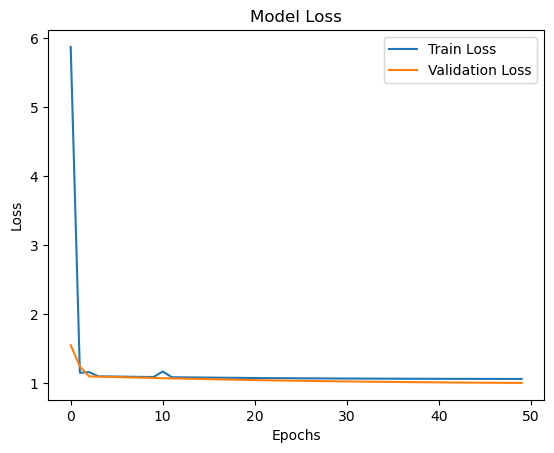

In [36]:
# Plot Confusion Matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Visualize training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Dense Net 121

In [38]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

# Load DenseNet121 model with pre-trained weights
densenet_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in densenet_base.layers:
    layer.trainable = False

# Add custom classification layers
model = Sequential([
    densenet_base,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(label_map), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)


In [39]:
# Train the model
history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_test, y_test),
                    epochs=50)


Epoch 1/50


C:\Users\shubh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.4233 - loss: 14.0510 - val_accuracy: 0.3043 - val_loss: 8.0857
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4579 - loss: 6.2086 - val_accuracy: 0.4457 - val_loss: 2.4557
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.4881 - loss: 1.7983 - val_accuracy: 0.4022 - val_loss: 1.0198
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.3420 - loss: 1.0097 - val_accuracy: 0.4565 - val_loss: 0.9933
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4525 - loss: 0.9759 - val_accuracy: 0.5652 - val_loss: 0.7140
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5056 - loss: 0.9416 - val_accuracy: 0.4674 - val_loss: 0.7573
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5142 - loss: 0.9118 - val_accuracy: 0.4565 - val_loss: 0.7520
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5167 - loss: 0.9157 - val_accuracy: 0.6739 - val_loss: 0.6993
Ep

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6527 - loss: 0.5999
Test Accuracy: 64.13%
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step

Classification Report:
              precision    recall  f1-score   support

         car       0.79      0.55      0.65        55
     cyclist       0.45      0.90      0.60        20
        tram       0.79      0.65      0.71        17

    accuracy                           0.64        92
   macro avg       0.68      0.70      0.65        92
weighted avg       0.71      0.64      0.65        92



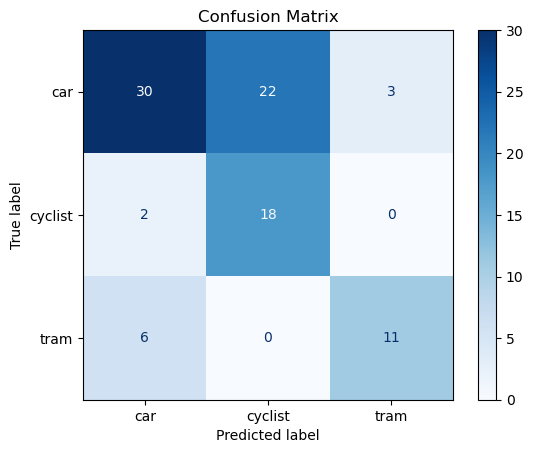

In [40]:
# Evaluate the model
loss, accuracy_densenet121 = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy_densenet121 * 100:.2f}%")

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=label_map.keys())

# Plot Confusion Matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


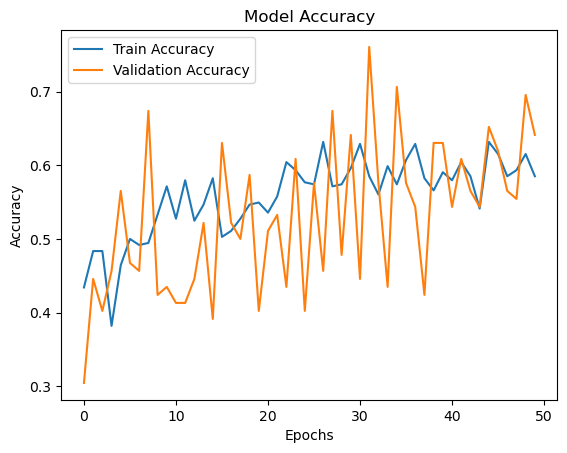

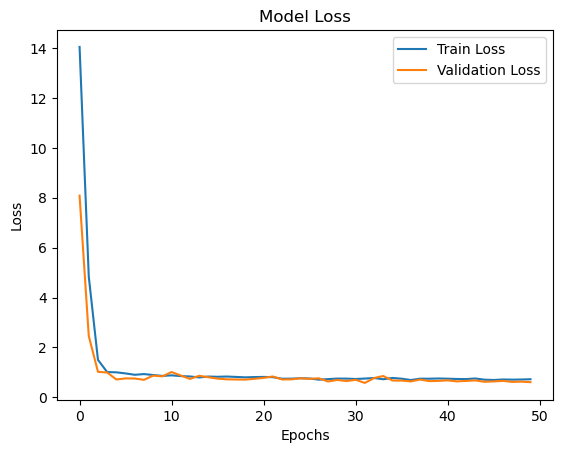

In [41]:
# Visualize training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

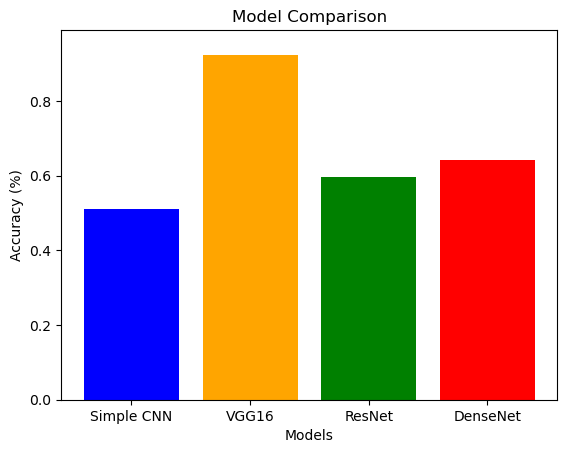

In [57]:
# Compare Models
model_names = ["Simple CNN", "VGG16", "ResNet", "DenseNet"]
accuracies = [accuracy_cnn, accuracy_vgg16, accuracy_resnet, accuracy_densenet121]

plt.bar(model_names, accuracies, color=['blue', 'orange', 'green', 'red'])
plt.title("Model Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.ylim(0, .99)
plt.show()


# Sensor Fusion with RL using Lidr and GPS data 

In [6]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
from matplotlib.image import imread
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from imgaug import augmenters as iaa

# Define paths to image, LIDAR, and GPS/IMU folders
image_folder = r"D:/Autonomous_project/KITTI_dataset/raw_dataset/2011_09_26/2011_09_26_drive_0001_sync/image_03/data"
lidar_folder = r"D:/Autonomous_project/KITTI_dataset/raw_dataset/2011_09_26/2011_09_26_drive_0001_sync/velodyne_points/data"
oxts_folder = r"D:/Autonomous_project/KITTI_dataset/raw_dataset/2011_09_26/2011_09_26_drive_0001_sync/oxts/data"
calib_cam_to_cam_path = r"D:/Autonomous_project/KITTI_dataset/raw_dataset/2011_09_26/calib/calib_cam_to_cam.txt"
calib_velo_to_cam_path = r"D:/Autonomous_project/KITTI_dataset/raw_dataset/2011_09_26/calib/calib_velo_to_cam.txt"

# Load calibration matrices
def load_calibration_matrices():
    # Load velo_to_cam calibration
    with open(calib_velo_to_cam_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith("R:"): #spliting the text to start after first index
                R = np.array([float(x) for x in line.split()[1:]]).reshape(3, 3)
            if line.startswith("T:"):
                T = np.array([float(x) for x in line.split()[1:]]).reshape(3, 1)

    # Load cam_to_cam calibration
    with open(calib_cam_to_cam_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith("P_rect_02:"):
                P_rect = np.array([float(x) for x in line.split()[1:]]).reshape(3, 4)

    return R, T, P_rect

R, T, P_rect = load_calibration_matrices()

In [8]:
# Transform LIDAR points to the camera frame
def transform_lidar_to_camera(lidar_points):
    # Convert to homogeneous coordinates
    lidar_points_h = np.hstack((lidar_points, np.ones((lidar_points.shape[0], 1))))
    # Apply rotation and translation
    lidar_in_camera_frame = np.dot(R, lidar_points_h[:, :3].T).T + T.T
    return lidar_in_camera_frame

# Project points to the image plane
def project_to_image_plane(camera_points):
    camera_points_h = np.hstack((camera_points, np.ones((camera_points.shape[0], 1))))
    image_points = np.dot(P_rect, camera_points_h.T).T
    # Normalize by the third coordinate
    image_points[:, 0] /= image_points[:, 2]
    image_points[:, 1] /= image_points[:, 2]
    return image_points[:, :2]

# Parse LIDAR points
def parse_lidar_file(lidar_file_path):
    return np.loadtxt(lidar_file_path, dtype=np.float32)

In [10]:
# Parse GPS/IMU data
def parse_oxts_file(oxts_file_path):
    with open(oxts_file_path, 'r') as f:
        data = f.readline().strip().split()
    return {
        "latitude": float(data[0]),
        "longitude": float(data[1]),
        "altitude": float(data[2]),
        "roll": float(data[3]),
        "pitch": float(data[4]),
        "yaw": float(data[5])
    }

# Filter valid images
def filter_valid_images():
    image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.png')])
    lidar_files = sorted([f for f in os.listdir(lidar_folder) if f.endswith('.bin')])
    oxts_files = sorted([f for f in os.listdir(oxts_folder) if f.endswith('.txt')])

    valid_image_files = [
        img_file for img_file in image_files
        if os.path.splitext(img_file)[0] in [os.path.splitext(lidar)[0] for lidar in lidar_files] and
           os.path.splitext(img_file)[0] in [os.path.splitext(oxts)[0] for oxts in oxts_files]
    ]
    return valid_image_files

valid_image_files = filter_valid_images()

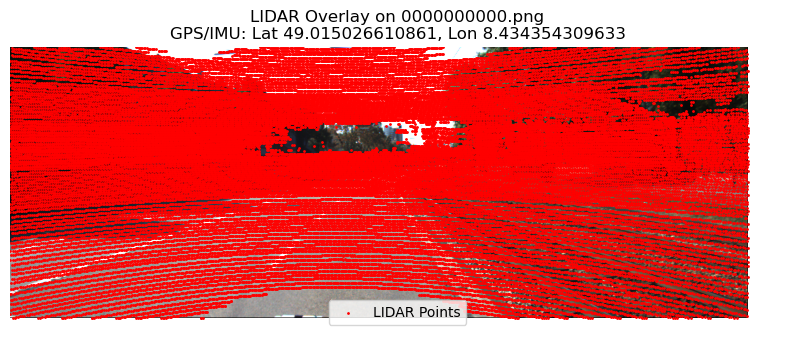

In [12]:
# Visualize LIDAR overlay on image
def visualize_lidar_overlay(image_file):
    base_name = os.path.splitext(image_file)[0]
    lidar_file = base_name + ".bin"
    oxts_file = base_name + ".txt"

    img_path = os.path.join(image_folder, image_file)
    lidar_path = os.path.join(lidar_folder, lidar_file)
    oxts_path = os.path.join(oxts_folder, oxts_file)

    # Check if LIDAR and GPS/IMU files exist
    if not os.path.exists(lidar_path) or not os.path.exists(oxts_path):
        print(f"Missing LIDAR or GPS/IMU data for {image_file}")
        return

    img = imread(img_path)
    lidar_points = parse_lidar_file(lidar_path)
    gps_imu = parse_oxts_file(oxts_path)

    # Transform and project LIDAR points
    lidar_in_camera_frame = transform_lidar_to_camera(lidar_points)
    image_points = project_to_image_plane(lidar_in_camera_frame)

    # Filter points that fall outside the image bounds
    img_h, img_w, _ = img.shape
    valid_indices = (
        (image_points[:, 0] >= 0) & (image_points[:, 0] < img_w) &
        (image_points[:, 1] >= 0) & (image_points[:, 1] < img_h)
    )
    image_points = image_points[valid_indices]

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.scatter(image_points[:, 0], image_points[:, 1], s=1, c='red', label='LIDAR Points')
    plt.title(f"LIDAR Overlay on {image_file}\nGPS/IMU: Lat {gps_imu['latitude']}, Lon {gps_imu['longitude']}")
    plt.legend()
    plt.axis('off')
    plt.show()

# Visualize first valid image
visualize_lidar_overlay(valid_image_files[0])

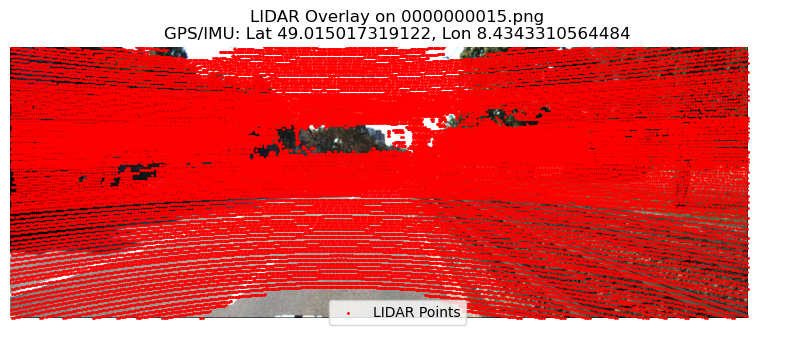

In [14]:
visualize_lidar_overlay(valid_image_files[15])


# Data augmentation

In [16]:
# Data augmentation
augmentation_pipeline = iaa.Sequential([
    iaa.Fliplr(0.5),
    iaa.Affine(rotate=(-10, 10)),
    iaa.Multiply((0.8, 1.2)),
    iaa.GaussianBlur(sigma=(0, 1.0))
])

def augment_images(image_files):
    augmented_images = []
    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented_img = augmentation_pipeline(image=img)
        augmented_images.append(augmented_img)
    return augmented_images

augmented_images = augment_images(valid_image_files)


In [17]:
# Split data into training, validation, and test sets (standard split)
train_files, test_files = train_test_split(valid_image_files, test_size=0.2, random_state=42)
train_files, val_files = train_test_split(train_files, test_size=0.1, random_state=42)

print(f"Training set: {len(train_files)} images")
print(f"Validation set: {len(val_files)} images")
print(f"Test set: {len(test_files)} images")

Training set: 79 images
Validation set: 9 images
Test set: 23 images


# Define KITTI RL Environment

In [21]:
# KITTI Environment
class KITTIEnvironment:
    def __init__(self, image_folder, lidar_folder, valid_image_files):
        self.image_folder = image_folder
        self.lidar_folder = lidar_folder
        self.image_files = valid_image_files
        self.current_index = 0

    def reset(self):
        self.current_index = 0
        return self._get_state(self.current_index)

    def step(self, action):
        reward = random.uniform(0, 1)  # Placeholder reward logic if the agent decision is correct a reward is given if it is incorrect a penalty is given
        done = self.current_index >= len(self.image_files) - 1
        self.current_index += 1
        next_state = self._get_state(self.current_index) if not done else None
        return next_state, reward, done, {}
# get the current state info 
    def _get_state(self, index):
        img_path = os.path.join(self.image_folder, self.image_files[index])
        lidar_path = os.path.join(self.lidar_folder, os.path.splitext(self.image_files[index])[0] + ".bin")

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (84, 84)) / 255.0

        # Load LIDAR points
        lidar_points = parse_lidar_file(lidar_path)

        # Transform and project LIDAR points
        lidar_in_camera_frame = transform_lidar_to_camera(lidar_points)
        image_points = project_to_image_plane(lidar_in_camera_frame)

        return {
            "image": img,
            "lidar": image_points
        }

# Initialize environment
env = KITTIEnvironment(image_folder, lidar_folder, train_files)

# DQN Model

In [24]:
# DQN Model
class DQN(nn.Module):
    def __init__(self, action_size):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, action_size)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = x.reshape(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Initialize DQN Model
action_size = 3  # left, right, forward
policy_net = DQN(action_size)
target_net = DQN(action_size)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

DQN(
  (conv1): Conv2d(3, 32, kernel_size=(8, 8), stride=(4, 4))
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
)

# Training the model

In [27]:
# Define training parameters
batch_size = 64 #num of samples for training during each iteration
gamma = 0.99 #gamma is tuned for bellmans equation q(s,a) = reward + gamma . q'(s,a)
epsilon = 1.0 #starting epsilon for exploration
epsilon_decay = 0.995 #step for epsilon
epsilon_min = 0.1 #min epsilon
learning_rate = 1e-4 #for adam optimizer
target_update = 10 #num of episodes after which the target network is updated (backpropogation)
num_episodes = 100 # total number of episodes to be training

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss() #MSE loss prediction between expected and actual Q values
replay_buffer = deque(maxlen=10000) # a memory to store the learning experiences from training 

# Training Loop
def train():
    if len(replay_buffer) < batch_size: #start after the buffer is filled with past training 
        return

    batch = random.sample(replay_buffer, batch_size) #randomly sample a batch 
    states, actions, rewards, next_states, dones = zip(*batch) #unpack the batch of 64 samples as defined
    #convert the state action reward and dones to tensors 
    states = torch.tensor(np.array(states), dtype=torch.float32).permute(0, 3, 1, 2) #(batchsize,channel,height,width)
    actions = torch.tensor(actions, dtype=torch.int64)
    rewards = torch.tensor(rewards, dtype=torch.float32)
    next_states = torch.tensor(np.array(next_states), dtype=torch.float32).permute(0, 3, 1, 2)
    dones = torch.tensor(dones, dtype=torch.float32)
    #pass current state and calculate q values for all the actions
    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    next_q_values = target_net(next_states).max(1)[0] #max q value for next state
    expected_q_values = rewards + gamma * next_q_values * (1 - dones) #Bellman's equation

    loss = loss_fn(q_values, expected_q_values.detach())
    optimizer.zero_grad() #clear previous gradients before backpropogation and updation
    loss.backward() #back propogation as feedback 
    optimizer.step() #updation step

# Main Training Loop
rewards_per_episode = [] #list to store rewards for each episodes
for episode in range(num_episodes):
    state = env.reset() #reset to get initial states
    total_reward = 0 #initialize total reward for episode
    for t in range(200):  # Max steps per episode
        if random.random() < epsilon:
            action = random.randint(0, action_size - 1)  # Explore and choose a random action
        else:
            state_tensor = torch.tensor(state["image"], dtype=torch.float32).unsqueeze(0).permute(0, 3, 1, 2)
            q_values = policy_net(state_tensor)
            action = torch.argmax(q_values).item()  #choose action with the highest q value

        next_state, reward, done, _ = env.step(action)  #execute taking action in the environment

        # Skip adding to replay buffer if next_state is None
        if next_state is not None:
            replay_buffer.append((state["image"], action, reward, next_state["image"], done)) #check if episodes are terminated

        state = next_state # update next state 
        total_reward += reward #give extra reward for each correct action

        # Train the model
        train() #training policy network after each step

        if done:
            break #break if episode ends

    rewards_per_episode.append(total_reward)
    epsilon = max(epsilon * epsilon_decay, epsilon_min) # decrease epsilon for less exploration

    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"Episode {episode}, Total Reward: {total_reward}")

Episode 0, Total Reward: 39.38428732545392
Episode 1, Total Reward: 40.51955640792279
Episode 2, Total Reward: 38.176307205384646
Episode 3, Total Reward: 39.525496599405606
Episode 4, Total Reward: 43.57998951960136
Episode 5, Total Reward: 39.29913962444997
Episode 6, Total Reward: 39.896028646862526
Episode 7, Total Reward: 38.03683242941352
Episode 8, Total Reward: 39.95341867035669
Episode 9, Total Reward: 43.209753112189595
Episode 10, Total Reward: 36.519977376956525
Episode 11, Total Reward: 38.53143773599945
Episode 12, Total Reward: 40.34935518900759
Episode 13, Total Reward: 36.712415407494625
Episode 14, Total Reward: 40.131163639192955
Episode 15, Total Reward: 40.12743748337326
Episode 16, Total Reward: 40.02355033143685
Episode 17, Total Reward: 40.80562859279364
Episode 18, Total Reward: 36.37970591350402
Episode 19, Total Reward: 40.185047027890135
Episode 20, Total Reward: 40.87380373313065
Episode 21, Total Reward: 43.89503225705977
Episode 22, Total Reward: 38.14447

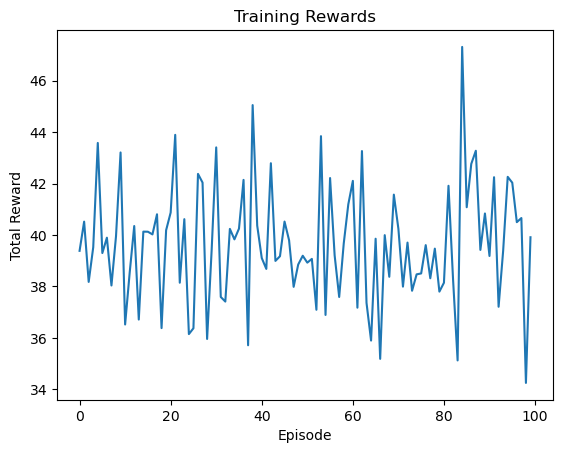

In [28]:
# Visualize Training Rewards
plt.plot(rewards_per_episode)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Rewards")
plt.show()

# Save the trained model
torch.save(policy_net.state_dict(), "dqn_kitti_model.pth")


# Evaluate the model

In [29]:
# Evaluate the model
def evaluate_model(env, policy_net, num_episodes=20):
    policy_net.eval()  # Set the model to evaluation mode
    total_rewards = []
    success_count = 0  # initialize a counter to count successful episodes

    for episode in range(num_episodes):
        state = env.reset() #reset to get the initial state
        episode_reward = 0 #reward counter for each episode 
        done = False # set to false to check if episode has ended

        while not done:
            state_tensor = torch.tensor(state["image"], dtype=torch.float32).unsqueeze(0).permute(0, 3, 1, 2) #unsqeexze because agent expects batch input
            with torch.no_grad():
                q_values = policy_net(state_tensor) #pass through the network to get q values
            action = torch.argmax(q_values).item()  # Select the best action which gives highest q value

            next_state, reward, done, _ = env.step(action)
            if next_state is not None:
                state = next_state
            episode_reward += reward

        total_rewards.append(episode_reward)
        if episode_reward > np.mean(total_rewards):  #threshold for success
            success_count += 1

    avg_reward = np.mean(total_rewards) #average reward for total episodes
    success_rate = success_count / num_episodes * 100 #calculate success rate

    print(f"Evaluation Results over {num_episodes} episodes:")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Success Rate: {success_rate:.2f}%")

    return avg_reward, success_rate


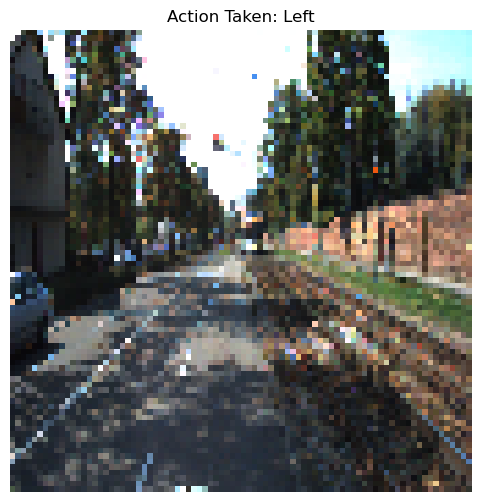

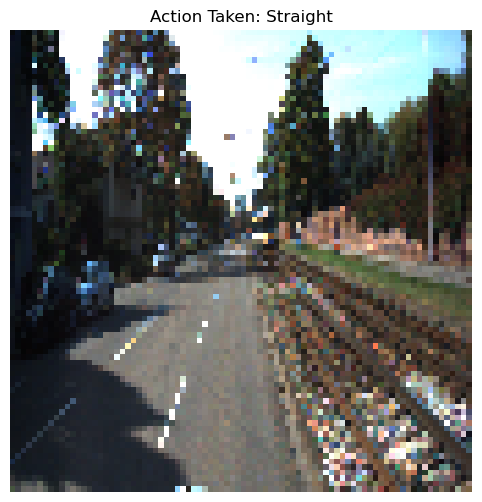

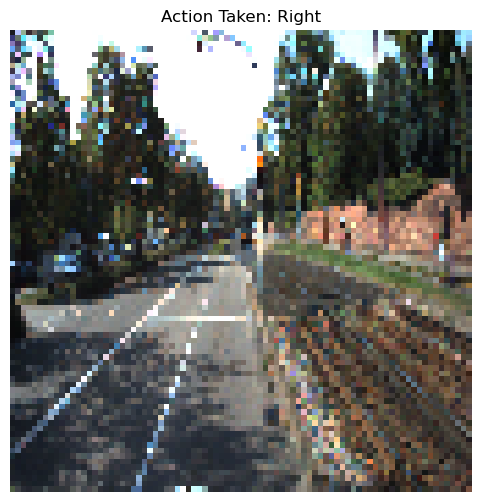

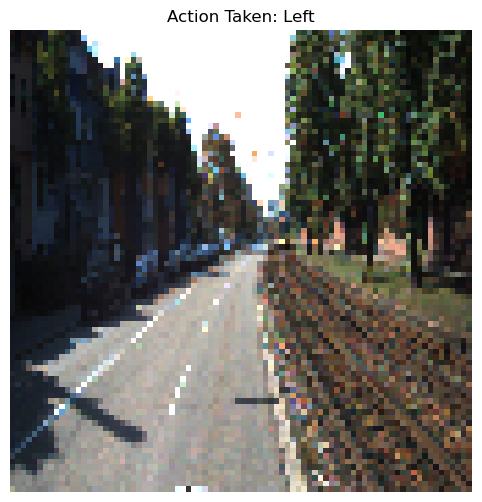

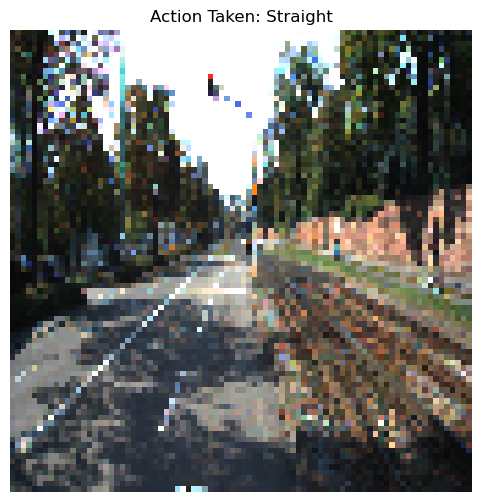

In [30]:
# Visualize agent decisions
def visualize_agent_decisions(env, policy_net, num_images=5):
    policy_net.eval()
    sampled_images = random.sample(env.image_files, num_images)

    for img_file in sampled_images:
        state = env._get_state(env.image_files.index(img_file))  # Load state

        # Predict the action
        state_tensor = torch.tensor(state["image"], dtype=torch.float32).unsqueeze(0).permute(0, 3, 1, 2)
        with torch.no_grad():
            q_values = policy_net(state_tensor)
        action = torch.argmax(q_values).item()

        # Visualize the action
        plt.figure(figsize=(10, 6))
        plt.imshow(state["image"])
        plt.title(f"Action Taken: {['Left', 'Straight', 'Right'][action]}")
        plt.axis('off')
        plt.show()

# Visualize decisions
visualize_agent_decisions(env, policy_net)
